# Еволюційні обчислення

##  Еволюційні алгоритми (ЕА)

Автор: Денніс Вілсон

## Зміст

1. [Індивіди](#individuals)
2. [Цільові функції](#objectives)
3. [(1+1) EA](#one_plus_one)
4. [$(1+\lambda)$ EA](#one_plus_lambda)
5. [Параметри алгоритму](#parameters)


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YKochura/ga-kpi/blob/main/practice/evolutionary_algorithms.ipynb)

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import math
import numpy as np
import time
from tqdm import tqdm
np.random.seed(1234)

In [2]:
# Відображення прогрес-бару в Python
for i in tqdm(range(100)):
  time.sleep(0.1)  # імітація тривалого процесу

100%|██████████| 100/100 [00:10<00:00,  9.79it/s]


## <a id="individuals"></a>Індивіди

Базовою одиницею еволюційного алгоритму є індивід. Індивід &mdash; це окремий розв’язок задачі, яку ми прагнемо вирішити. Для початку розглянемо найпростіший випадок &mdash; бінарних індивідів, у яких гени представлені бітами (0 та 1).

У біологічних організмах ДНК зазвичай має основу 4, тобто представлена чотирма нуклеотидами: аденін (А), гуанін (Г), цитозин (Ц) і тимін (Т). У нашому випадку ми використовуватимемо двійкове (бінарне) подання &mdash; лише з 1 і 0. Водночас, навіть таке спрощене представлення може описувати надзвичайно складні системи.

Бінарне кодування є зручним для проведення теоретичного аналізу еволюційних алгоритмів, оскільки більшість досліджень у цій галузі виконувались саме на основі бінарних геномів.

In [3]:
class Individual:

  def __init__(self, n: int):
    self.genes = np.random.randint(0, 2, (n,))
    self.fitness = -np.inf

  def __str__(self):
    return f'(Ind: {self.genes}, {self.fitness})'

  def __repr__(self):
    return str(self)

Тут ми визначили клас &mdash; `Individual`, який має бінарні гени та цілочисельне подання для пристосованості (fitness).

Під час створення нового індивіда його гени генеруються випадковим чином, а значення пристосованості за замовчуванням встановлюється рівним 0.

У наведених прикладах ми будемо використовувати цільові функції (objective functions), які повертають позитивні значення пристосованості.

In [4]:
ind = Individual(10)
ind

(Ind: [1 1 0 1 0 0 0 1 1 1], -inf)

## <a id="objectives"></a>Цільові функції

**Цільова функція** &mdash; це функція, яка визначає пристосованість (fitness) індивіда до умов задачі.

Однією з ключових переваг еволюційних алгоритмів є те, що цільова функція може бути будь-якою, головне &mdash; щоб вона могла оцінити індивіда. На відміну від багатьох інших методів оптимізації, така функція **не обов’язково повинна бути диференційованою (неперервною)**.

Першою цільовою функцією, яку ми розглянемо, буде функція **OneMax**. Вона дуже проста: підсумовує всі біти в генотипі. Тобто рахує кількість одиниць.

Оптимальне значення пристосованості в цьому випадку досягається тоді, коли весь генотип складається лише з 1. Ця функція добре вивчена в теорії та є корисною для узагальнення задачі пошуку довільного бітового рядка.

In [5]:
def onemax(i: Individual):
    return np.sum(i.genes)

In [6]:
ind.fitness = onemax(ind)
ind

(Ind: [1 1 0 1 0 0 0 1 1 1], 6)

Як ми бачимо, пристосованість нашого індивіда визначається кількістю одиничних бітів.

Щоб забезпечити більшу гнучкість у майбутньому, ми напишемо функцію `evaluate`, яка зможе приймати будь-яку цільову функцію (objective function).

In [7]:
def evaluate(ind: Individual, objective):
    ind.fitness = objective(ind)

evaluate(ind, onemax)
ind

(Ind: [1 1 0 1 0 0 0 1 1 1], 6)

Тепер, коли ми визначили наших індивідів і маємо цільову функцію, ми готові написати наш перший еволюційний алгоритм.

## <a id="one_plus_one"></a>(1+1) Еволюційний алгоритм

Першим алгоритмом, який ми реалізуємо буде (1+1) еволюційний алгоритм:

1. Випадковим чином обираємо початковий бітовий рядок $x∈ \{0;1\} $
2. Повторюємо наступний крок мутації:
    1. Обчислюємо $x′$, змінюючи кожен біт $x_i$ незалежно з ймовірністю $p$.
    2. Заміняємо $x$ на $x′$, якщо $f(x′) \geq f(x)$.

Ми почнемо з визначення кількості вимірів для нашої задачі, а потім визначимо першого індивіда, що стане початковою точкою пошуку.

In [8]:
n = 20

In [9]:
parent = Individual(n)
parent

(Ind: [1 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0], -inf)

In [10]:
evaluate(parent, onemax)
parent

(Ind: [1 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0], 6)

Давайте визначимо крок мутації як функцію. Це зробить наш код більш організованим. Використаємо ймовірність мутації $p = \frac{1}{n}$, де $n$ — кількість бітів. Про цей вибір ми поговоримо трохи пізніше.

In [11]:
def mutate(ind: Individual, mutation_rate=1.0/len(ind.genes)):
  new_genes = np.copy(ind.genes)
  for i in range(len(new_genes)):
      if np.random.rand() < mutation_rate:
          new_genes[i] = not ind.genes[i]
  child = Individual(len(ind.genes))
  child.genes = new_genes
  return child

In [12]:
child = mutate(parent)
print("Parent :", parent)
print("Child  :", child)
print("Genes  :", parent.genes == child.genes)

Parent : (Ind: [1 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0], 6)
Child  : (Ind: [1 1 1 0 1 0 0 1 0 0 0 0 0 0 1 0 1 1 0 0], -inf)
Genes  : [ True  True False  True  True  True  True False  True  True  True  True
  True  True  True  True  True  True  True  True]


Спробуйте виконати цей алгоритм кілька разів, і ви побачите, що зазвичай змінюється лише один біт. Це логічно, оскільки ми встановили ймовірність мутації $p = \frac{1}{n}$. Це означає, що еволюція буде рухатись досить повільно до оптимального бітового рядка, адже в середньому змінюється лише один біт за раз.

Тепер, коли ми маємо нового індивіда, ми можемо виконати останню частину нашого алгоритму: замінити $x$ на $x′$, якщо $f(x′) \geq f(x)$. Для цього нам спочатку потрібно оцінити нового індивіда.

In [13]:
evaluate(child, onemax)
print(parent.fitness)
print(child.fitness)
if child.fitness >= parent.fitness:
    parent = child
parent.fitness

6
8


np.int64(8)

Це всі кроки, які стосуються (1+1) еволюційного алгоритму. Ми просто повторюємо крок мутації знову і знову, поки не досягнемо бажаного розв’язку або не зупинимо обчислення. Розглянемо лише кілька ітерацій:

In [14]:
parent = Individual(n)
for i in range(20):
    child = mutate(parent)
    evaluate(child, onemax)
    if child.fitness >= parent.fitness:
        parent = child
    # print(i, " ", parent.fitness)

print(parent.fitness, " / ", n)

15  /  20


Отже, за кілька поколінь ми можемо побачити покращення. Щоб дослідити, скільки часу знадобиться для досягнення розв'язку OneMax, давайте спочатку визначимо все, що ми зробили до цього часу, як функцію.

In [15]:
def one_plus_one(ind_length: int, num_generations: int, objective):
  fits = np.zeros(num_generations)
  parent = Individual(ind_length)
  evaluate(parent, objective)

  for i in tqdm(range(len(fits))):
      child = mutate(parent)
      evaluate(child, objective)

      if child.fitness >= parent.fitness:
          parent = child

      fits[i] = parent.fitness
  return fits

Оскільки еволюційні алгоритми є стохастичними, важко гарантувати їх точну обчислювальну складність. Можна довести найгірший випадок, але більш корисною метрикою є очікувана кількість поколінь для досягнення оптимального розв'язку. Для лінійних цільових функцій, таких як задача OneMax, було [доведено](https://core.ac.uk/download/pdf/82100186.pdf), що очікуваний час роботи для (1+1) EA становить $O(n \log n)$, де $n$ — кількість незалежних бінарних змінних (тобто довжина геному). Це доведення виходить за межі цього завдання, але рекомендується ознайомитись з вказаною публікацією. Зверніть увагу, що це стосується тільки випадку, коли ймовірність мутації дорівнює $\frac{1}{n}$, саме тому ми використовували її як значення за замовчуванням раніше.

Давайте запустимо наш (1+1) EA з кількістю поколінь $n \log n$.

In [16]:
n = 1000
fits = one_plus_one(n, int(np.round(n * np.log(n))), onemax)
print(fits[-1])

100%|██████████| 6908/6908 [00:05<00:00, 1253.72it/s]

657.0


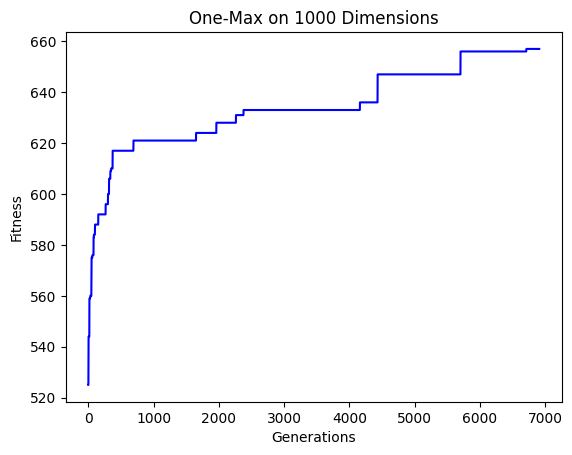

In [17]:
plt.plot(fits, 'b')
plt.xlabel("Generations")
plt.ylabel("Fitness")
plt.title(f"One-Max on {n} Dimensions");

Це ще не зовсім $n$, але дуже близько, що й гарантує очікуваний час: $n \log n$ — це середнє значення часу, коли (1+1) EA сходиться. Найгірший випадок для бінарного (1+1) EA для будь-якої функції — це збіжність за $O(n^n)$, але нам не потрібно запускати алгоритм так довго, щоб побачити збіжність.

Задача **Leading Ones** — це ще одна добре вивчена бінарна задача, яка підраховує кількість одиничних бітів, які зустрічаються підряд зліва направо, зупиняючись, коли досягнуто перший нульовий біт. Іншими словами, пристосованість цієї функції визначається наступним чином:

$f(x) := \sum_{i=1}^n \prod_{j=1}^i x_j$

У нашій реалізації ми просто підраховуємо індекси і зупиняємося, коли досягаємо 0.

In [18]:
def leading_ones(ind: Individual):
  f = 0
  for i in range(len(ind.genes)):
      if not ind.genes[i]:
          f = i
          break
  return f
print(ind)
leading_ones(ind)

(Ind: [1 1 0 1 0 0 0 1 1 1], 6)


2

<div class="alert alert-success">
    <b>Вправа</b>
    <br/>
    Запустіть (1+1) EA для задачі Leading Ones. Як він зходиться $O(n \log n)$ чи $O(n^2)$?
    <br/>
</div>

## <a id="one_plus_lambda"></a>$(1+\lambda)$ Еволюційний алгоритм

Наступний алгоритм, який ми розглянемо, є невеликою модифікацією над (1+1) EA. Замість того, щоб генерувати одного індивіда на кожній ітерації (поколінні), ми будемо генерувати $\lambda$ індивідів. Це можна вважати нашою популяцією. Ця маленька зміна означає, що алгоритм $(1+\lambda)$ все ще дуже простий, але саме цей простий алгоритм використовується в передових методах генетичного програмування для виконання складних завдань.

Алгоритм $(1+\lambda)$ EA вводить новий параметр: розмір популяції. Як обрати цей параметр? Нещодавні теоретичні дослідження продемонстрували, що очікуваний час виконання алгоритму $(1+\lambda)$ EA для будь-якої лінійної функції становить $O(\frac{1}{λ} n \log n + n)$ за умови, що $\lambda = O(\log n \log \log n / \log \log \log n)$. Ми можемо спробувати цей варіант.

In [19]:
n = 1000
𝜆 = int(round(np.log(n)*np.log(np.log(n))/np.log(np.log(np.log(n)))))
print(𝜆)

20


Перепишемо нашу функцію `one_plus_one`, цього разу використовуючи популяцію індивідів. Ми будемо відстежувати найкращого нового індивіда, щоб порівняти його з "експертом" (поточним найкращим) для заміни в наступному поколінні.

In [20]:
m = 1
a = [0]
for i in range(1, m+1):
  a.append(i)
print(a)

[0, 1]


In [21]:
def one_plus_lambda(ind_length: int, num_generations: int, objective, 𝜆: int):
  fits = np.zeros(num_generations)
  expert = Individual(ind_length)
  evaluate(expert, objective)

  for i in tqdm(range(len(fits))):
      population = [expert,]
      best = 0
      for j in range(1, 𝜆):
          population.append(mutate(expert))
          evaluate(population[j], objective)
          if population[j].fitness > population[best].fitness:
              best = j
      if population[best].fitness >= expert.fitness:
          expert = population[best]
      fits[i] = expert.fitness
  return fits

Давайте порівняємо ці два методи на задачі **OneMax**.

In [22]:
n = 100
n_gens = 1000
fits_1 = one_plus_one(n, n_gens, onemax)
fits_𝜆 = one_plus_lambda(n, n_gens, onemax, 𝜆)
fits_1[-1], fits_𝜆[-1]

100%|██████████| 1000/1000 [00:01<00:00, 546.48it/s]


(np.float64(85.0), np.float64(93.0))

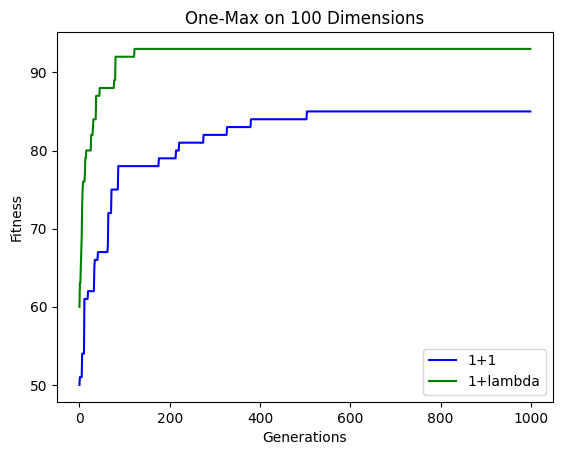

In [23]:
plt.plot(fits_1, label="1+1", color='b')
plt.plot(fits_𝜆, label="1+lambda", color='g')
plt.xlabel("Generations")
plt.ylabel("Fitness")
plt.title(f"One-Max on {n} Dimensions")
plt.legend();

На перший погляд здається, що алгоритм $(1+\lambda)$ EA працює значно краще, ніж (1+1) EA. Однак таке порівняння є некоректним. Алгоритм $(1+\lambda)$ EA виконує оцінку функції $\lambda$ разів на кожне покоління, що означає набагато більше обчислень. Ми можемо побачити це, якщо побудуємо графік не за поколіннями, а за кількістю викликів функції оцінки.

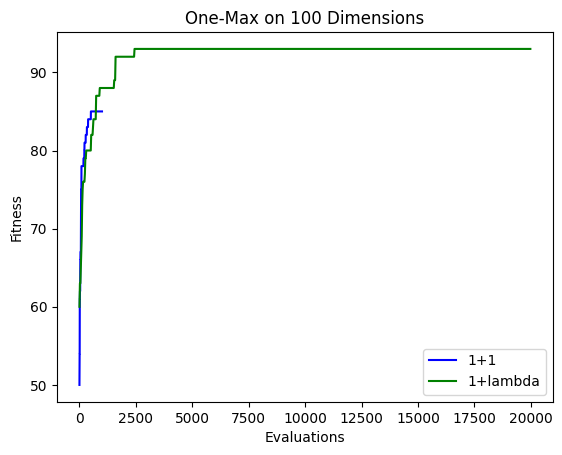

In [24]:
plt.plot(fits_1, label="1+1", color='b')
plt.plot(np.arange(1,n_gens*𝜆,𝜆), fits_𝜆, label="1+lambda", color='g')
plt.xlabel("Evaluations")
plt.ylabel("Fitness")
plt.title(f"One-Max on {n} Dimensions")
plt.legend();

Більш справедливим порівнянням буде надати кожному алгоритму однакову кількість викликів функції оцінки, ось так:

In [25]:
n = 1000
n_gens = 10000
fits_1 = one_plus_one(n, n_gens, onemax)
fits_𝜆 = one_plus_lambda(n, int(n_gens/𝜆), onemax, 𝜆)

100%|██████████| 500/500 [00:06<00:00, 75.15it/s]


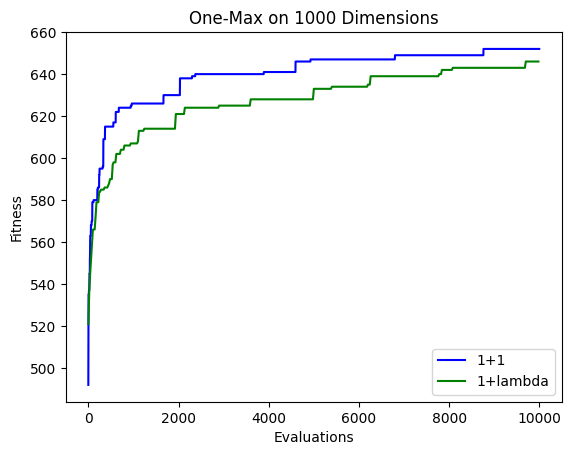

In [26]:
plt.plot(fits_1, label="1+1", color='b')
plt.plot(np.arange(1,n_gens,𝜆), fits_𝜆, label="1+lambda", color='g')
plt.xlabel("Evaluations")
plt.ylabel("Fitness")
plt.title(f"One-Max on {n} Dimensions")
plt.legend();

Оскільки еволюційні алгоритми повністю ґрунтуються на випадковості, гарною практикою є запускати їх багаторазово, щоб отримати уявлення про їхню ефективність. Ми виконаємо 10 запусків, але в багатьох випадках доцільно робити більше повторень — залежно від розподілу фінальних результатів.

In [27]:
n_trials = 10
n = 100
n_gens = 1000

fits_1 = np.zeros((n_gens, n_trials))
fits_𝜆 = np.zeros((int(n_gens/𝜆), n_trials))

for i in range(n_trials):
    fits_1[:, i] = one_plus_one(n, n_gens, onemax)
    fits_𝜆[:, i] = one_plus_lambda(n, int(n_gens/𝜆), onemax, 𝜆)

100%|██████████| 50/50 [00:00<00:00, 538.90it/s]


In [28]:
μ_1 = np.mean(fits_1, axis=1)
σ_1 = np.std(fits_1, axis=1)
μ_𝜆 = np.mean(fits_𝜆, axis=1)
σ_𝜆 = np.std(fits_𝜆, axis=1)
print(np.shape(μ_1), np.shape(σ_1))
print(np.shape(μ_𝜆), np.shape(σ_𝜆))

(1000,) (1000,)
(50,) (50,)


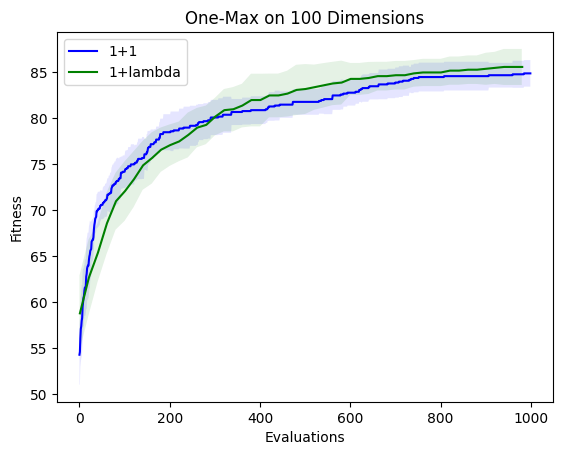

In [29]:
plt.plot(μ_1, label="1+1", color='b')
plt.fill_between(np.arange(0, n_gens), μ_1+σ_1, μ_1-σ_1, facecolor='b', alpha=0.1)
plt.plot(np.arange(1,n_gens,𝜆), μ_𝜆, label="1+lambda", color='g')
plt.fill_between(np.arange(0, n_gens, 𝜆), μ_𝜆+σ_𝜆, μ_𝜆-σ_𝜆, facecolor='g', alpha=0.1)
plt.xlabel("Evaluations")
plt.ylabel("Fitness")
plt.title(f"One-Max on {n} Dimensions")
plt.legend();

<div class="alert alert-success">
    <b>Вправа</b>
    <br/>
    Порівняйте (1+1) EA та $(1+\lambda)$ EA для задачі Leading Ones.
    <br/>
</div>

## <a id="parameters"></a>Параметри алгоритму

У цьому навчальному матеріалі ми використовували фіксовані значення параметрів, засновані на теоретичних результатах. Проте на практиці вибір ймовірності мутації та розміру популяції може суттєво впливати на експериментальні результати. Останні дослідження також демонструють ефективність [самоналаштовуваних параметрів](https://arxiv.org/pdf/1704.02191.pdf), подібно до того, як це реалізується в іншому стохастичному методі оптимізації — методі імітаційного відпалу (simulated annealing). Політика налаштування параметрів залишається активною сферою досліджень.

<div class="alert alert-info">
    <b>Вправа</b>
    <br/>
    Дослідіть вплив розміру популяції $\lambda$ та ймовірності мутації на $(1+1)$ EA та $(1+\lambda)$ EA. Чи суттєво змінюють вони результати? Реалізуйте динамічну ймовірність мутації, наприклад, таку, що зменшується з часом.
    <br/>
</div>